<a href="https://colab.research.google.com/github/Chuksjattu/TKH/blob/main/Copy_of_p1w7w8_data_viz_review_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Data Visualization Review — Weeks 7 & 8
### Topics: Pandas, Plot Types, Data Cleaning, and More

---

Welcome to the review session! This notebook covers:
- Working with DataFrames
- Creating plots
- Choosing the right chart
- Data cleaning
- Unit testing your data
- Feature engineering with dates

### 📖 How Each Section Is Structured

Every part follows the same four-step format:

| Step | What It Is                                                                                 |
|------|----------------------------------------------------------------------------|
| 1    | **Business Scenario** — the real-world context we're working in            |
| 2    | **Demo** — Walking through a solved example                                |
| 3    | **Guided Practice** — we solve this one together as a class                |
| 4    | **Your Turn** — you solve this one on your own or with your group members  |

---

## 🛠️ Environment Setup

Before running any code, follow these steps to create and activate a virtual environment.

### Step 1 — Create the virtual environment

Open your terminal, navigate to your project folder, and run:

```bash
python -m venv venv
```

> This creates a folder called `venv` inside your project directory that will hold all your packages.

### Step 2 — Activate the virtual environment

**Mac / Linux:**
```bash
source venv/bin/activate
```

**Windows (Command Prompt):**
```bash
venv\\Scripts\\activate
```

**Windows (PowerShell):**
```bash
venv\\Scripts\\Activate.ps1
```

> Once activated, you should see `(venv)` at the start of your terminal prompt.

### Step 3 — Install packages

Run the cell below to install all required packages into your virtual environment.

In [ ]:
# ⬇️ Run this cell once to install all required packages
%pip install pandas matplotlib numpy

### Step 4 — Import the libraries

In [ ]:
# ✅ Run this cell to import everything you'll need
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

print("Libraries loaded successfully!")

Libraries loaded successfully!


---
## Part 1: Working with DataFrames

A **DataFrame** is Pandas' core data structure — a two-dimensional table where rows are observations and columns are features. Knowing how to select and filter data is the foundation of everything else we do.

Key tools:
- `df['col']` — select a single column (returns a **Series**)
- `df[['col1', 'col2']]` — select multiple columns (returns a **DataFrame**)
- `df.loc[condition, 'col']` — filter rows by a condition and return a specific column

###  Business Scenario

##### You are a data analyst at **TechCorp**, a mid-sized software company. HR has given you a spreadsheet of employee records and asked you to pull specific subsets of data to answer management's questions.

In [ ]:
# 🏃 Run this to load the TechCorp employee dataset
data = {
    'Name':       ['Alice', 'Bob', 'Carol', 'David', 'Eve', 'Frank', 'Grace'],
    'Department': ['Sales', 'Engineering', 'Sales', 'HR', 'Engineering', 'HR', 'Sales'],
    'Salary':     [55000, 95000, 62000, 48000, 102000, 51000, 58000],
    'YearsExp':   [3, 7, 5, 2, 9, 4, 6],
    'Score':      [88, 95, 79, 72, 98, 74, 85]
}
df = pd.DataFrame(data)
df

,Name,Department,Salary,YearsExp,Score
0,Alice,Sales,55000,3,88
1,Bob,Engineering,95000,7,95
2,Carol,Sales,62000,5,79
3,David,HR,48000,2,72
4,Eve,Engineering,102000,9,98
5,Frank,HR,51000,4,74
6,Grace,Sales,58000,6,85


###  Demo — Select Multiple Columns

**Management asks:** *"Can you give us a list of just employee names and their salaries?"*

We only need two columns out of the full DataFrame. We pass a **list** of column names inside the brackets.

In [ ]:
# Demo: select the Name and Salary columns
df[['Name', 'Salary']]

,Name,Salary
0,Alice,55000
1,Bob,95000
2,Carol,62000
3,David,48000
4,Eve,102000
5,Frank,51000
6,Grace,58000


###  Guided Practice — Select a Single Column

**Management asks:** *"What departments do we have employees in?"*

**What we need to do:**
- Select only the `Department` column from `df`
- Remember: selecting a **single** column uses single brackets and returns a **Series**, not a DataFrame

In [ ]:
# Let's write this together


### 🏋️ Your Turn — Filter Rows with `.loc`

**Management asks:** *"Who are our highest earners? Give me the names of everyone earning more than $60,000."*

**What you need to do:**
1. Use `.loc` to filter rows where `Salary` is greater than `60000`
2. Return only the `Name` column for those filtered rows
3. Run the cell and confirm the names in the output make sense based on the full DataFrame above

In [ ]:
# Your code here


<details>
<summary>💡 Hint</summary>

Use `.loc` with a condition and a column name:
```python
df.loc[df['column'] > value, 'other_column']
```
- The part **before** the comma = which rows to keep
- The part **after** the comma = which column to return

</details>

---
## 📈 Part 2: Creating Plots

Pandas has built-in plotting through `.plot()` which sits on top of Matplotlib. Every chart type uses the same basic pattern:

```python
df.plot(kind='chart_type', x='col', y='col')
plt.title('Title')
plt.show()
```

The main chart types and when to use them:

| Chart | `kind=` | Best For |
|-------|---------|----------|
| Line | `'line'` | Trends over time |
| Bar | `'bar'` | Comparing categories |
| Scatter | `'scatter'` | Relationship between two numeric variables |
| Histogram | `'hist'` | Distribution of values |
| Boxplot | `'box'` | Spread and outliers |

### Business Scenario

##### Management at TechCorp wants visual summaries of the employee data. Charts make it much easier to spot patterns and communicate findings to non-technical stakeholders. You will create several charts to answer their questions.

###  Demo — Bar Chart

**Management asks:** *"Which department has the highest average performance score?"*

A bar chart is perfect here — we are comparing a single value (average score) across discrete categories (departments). We use `.groupby()` to calculate the average per department first, then chain `.plot` while providing the x-axis with Department and y-axis with Score and making the Plot into a Bar by providing the `kind` parameter with "bar" onto the result.

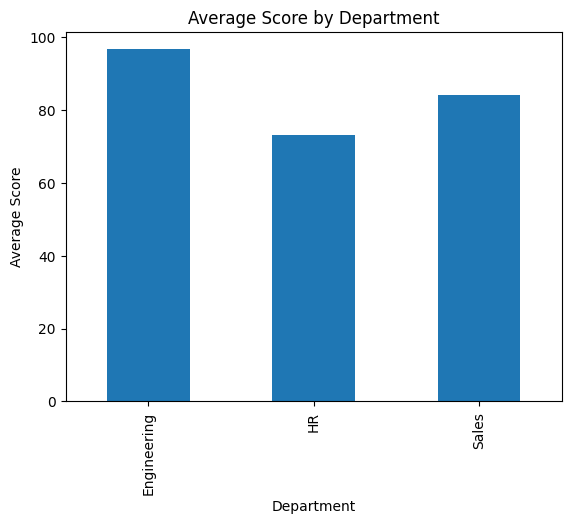

In [ ]:
# Demo: average Score by Department
groupedDf = df.groupby('Department')

groupedDf['Score'].mean().plot(x="Department", y="Score", kind="bar")

# OR (for Simplicity)
# df.groupby('Department')['Score'].mean().plot.bar()

plt.title('Average Score by Department')
plt.ylabel('Average Score')
plt.show()

### Guided Practice — Bar Chart (Average Salary)

**Management asks:** *"What is the average salary in each department?"*

**What we need to do:**
1. Use `.groupby()` to group `df` by `Department`
2. Select the `Salary` column and calculate the **mean**
3. Chain `.plot.bar()` onto the result
4. Add a title `'Average Salary by Department'` and a y-axis label `'Average Salary ($)'`
5. Call `plt.show()`

In [ ]:
# Let's write this together


### 🏋️ Your Turn — Scatter Plot

**Management asks:** *"Does more experience actually lead to higher scores? Show us the relationship visually."*

**What you need to do:**
1. Create a scatter plot using `df.plot.scatter()` with `YearsExp` on the x-axis and `Score` on the y-axis
2. Add a descriptive title that management would understand
3. Call `plt.show()`
4. In the Markdown cell below the chart, write one sentence describing the pattern — is the relationship positive, negative, or unclear?

In [ ]:
# Your code here


*Your observation here...*

<details>
<summary>💡 Hint</summary>

```python
df.plot.scatter(x='col1', y='col2')
plt.title('Your Title')
plt.show()
```

**How to read a scatter plot:** Look for an upward trend (positive correlation), downward trend (negative), or no clear pattern (no correlation).

</details>

---
## Part 3: Choose the Right Chart

Picking the wrong chart type can mislead your audience or obscure the insight entirely. The decision comes down to two questions:
1. **What type of data do I have?** (numeric vs. categorical, one variable vs. two)
2. **What story am I trying to tell?** (trend, comparison, distribution, relationship, proportion)

### Business Scenario

##### You've just joined a data team at **RetailCo**, a national retail chain. Your manager keeps sending you data questions and asking for visualizations. Before writing any code, you need to decide which chart type is appropriate for each request — picking the wrong one wastes time and can send the analysis in the wrong direction.

###  Demo — Matching a Chart to a Question

**Manager asks:** *"I want to know if there's a relationship between the amount a customer spends per visit and the number of times they visit per month."*

**Answer: Scatter Plot**

**Why:** We have two numeric variables — spend per visit and number of visits — and we want to see if they move together. A scatter plot puts one variable on each axis and lets us spot correlation visually. A bar chart would be wrong because neither variable is a category. A line chart would be wrong because there is no time dimension here.

### 🏋️ Your Turn

**Your manager sends you five more requests. Fill in the table on your own.**

For each scenario, identify the best chart type and write a one-sentence justification. There is no code to write here — this is about your reasoning.

| Manager's Request | Best Chart Type | Why? |
|-------------------|----------------|------|
| "How are our product return rates distributed across stores? I want to see if most stores are similar or if some are real outliers." | | |
| "What percentage of our total sales came from each product category last quarter?" | | |
| "Compare the total number of transactions processed by each of our five store locations." | | |
| "I want to see the spread of customer ages and flag any unusual values in the data." | | |
| "Does a higher marketing spend in a given week lead to more units sold that week?" | | |

<details>
<summary>💡 Hint</summary>

Use this framework to guide your choices:

| Chart | Best For |
|-------|----------|
| **Line Plot** | Change over time (continuous x-axis) |
| **Bar Chart** | Comparing a value across discrete categories |
| **Pie Chart** | Parts of a whole — use only with ≤6 categories |
| **Histogram** | Distribution of a single numeric variable; spotting skew |
| **Boxplot** | Spread, median, and outliers of a numeric variable |
| **Scatter Plot** | Relationship / correlation between two numeric variables |

</details>

---
## Part 4: Data Cleaning

Real-world data is almost never clean. Common issues include:
- **Wrong data types** — dates stored as text, numbers stored as strings with symbols like `$` or `,`
- **Missing values** — blank cells that appear as `NaN`, `None`, or `NaT`
- **Duplicates** — the same record appearing more than once
- **Inconsistent formatting** — `'NY'` vs `'New York'`, `'yes'` vs `'YES'`

Cleaning must happen **before** visualization — otherwise your charts will be wrong or will break entirely.

### Business Scenario

##### You're a python programmer at **ShopEasy**, an e-commerce company. A colleague exported the order history from the database and handed it to you as a CSV. Before you can build any sales reports or charts, you need to fix the problems in the data.

In [ ]:
# 🏃 Run this to load the ShopEasy order dataset
dirty_data = {
    'Order_ID':   [101, 102, 103, 104, 105, 102, 106],
    'Order_Date': ['2023-03-15', '2023-07-22', '2023-11-05', '2023-01-08', None, '2023-07-22', '2023-09-30'],
    'Sales':      ['$1,200.00', '$850.00', '$2,100.00', None, '$500.00', '$850.00', '$750.00'],
    'Region':     ['East', 'west', 'East', 'WEST', 'East', 'west', 'East']
}
dirty_df = pd.DataFrame(dirty_data)
dirty_df

,Order_ID,Order_Date,Sales,Region
0,101,2023-03-15,"$1,200.00",East
1,102,2023-07-22,$850.00,west
2,103,2023-11-05,"$2,100.00",East
3,104,2023-01-08,None,WEST
4,105,None,$500.00,East
5,102,2023-07-22,$850.00,west
6,106,2023-09-30,$750.00,East


###  Demo — Fix the Date Column

**Problem:** The `Order_Date` column looks like dates, but Pandas loaded it as `object` (plain text). That means we cannot sort chronologically, cannot do date math, and cannot use `.dt` to extract parts like month or day.

**Fix:** Use `pd.to_datetime()` to convert the column to `datetime64`. The `errors='coerce'` argument turns any unparseable value into `NaT` instead of crashing.

In [ ]:
# Demo: check the current type, then convert it
print("Before:", dirty_df['Order_Date'].dtype)

dirty_df['Order_Date'] = pd.to_datetime(dirty_df['Order_Date'], errors='coerce')

print("After: ", dirty_df['Order_Date'].dtype)
dirty_df[['Order_ID', 'Order_Date']]

Before: object
After:  datetime64[ns]


,Order_ID,Order_Date
0,101,2023-03-15
1,102,2023-07-22
2,103,2023-11-05
3,104,2023-01-08
4,105,NaT
5,102,2023-07-22
6,106,2023-09-30


### Guided Practice — Standardize the Region Column

**Problem:** The `Region` column has inconsistent capitalization — `'East'`, `'west'`, and `'WEST'` should all be the same value. If we group by Region right now, `'west'` and `'WEST'` will be counted as two separate regions.

**What we need to do:**
1. Print the unique values in `Region` before the fix so we can see the problem
2. Use the `.str` accessor with a string method to make every value the same case — `.str.title()` will capitalize the first letter of each word
3. Print the unique values again after the fix to confirm it worked

In [ ]:
# Let's write this together
print("Before:", dirty_df['Region'].unique())

# Fix goes here

print("After: ", dirty_df['Region'].unique())

Before: ['East' 'west' 'WEST']
After:  ['East' 'west' 'WEST']


### 🏋️ Your Turn — Fix the Sales Column

**Problem:** The `Sales` column contains values like `'$1,200.00'`. Because of the `$` and `,`, Pandas stored it as text — you cannot add, average, or plot it as a number.

**What you need to do:**
1. Use `.str.replace()` to remove the `$` sign from the `Sales` column
2. Use `.str.replace()` again to remove the `,` character
3. Use `pd.to_numeric()` with `errors='coerce'` to convert the column to `float64`
4. Print `dirty_df['Sales'].dtype` to confirm the dtype is now `float64`
5. Display `dirty_df` to verify the values look correct

In [ ]:
# Your code here


<details>
<summary>💡 Hint</summary>

**Steps 1 & 2** — Remove unwanted characters using the `.str` accessor:
```python
dirty_df['Sales'] = dirty_df['Sales'].str.replace('$', '', regex=False)
dirty_df['Sales'] = dirty_df['Sales'].str.replace(',', '', regex=False)
```

**Step 3** — Convert the cleaned strings to numbers:
```python
dirty_df['Sales'] = pd.to_numeric(dirty_df['Sales'], errors='coerce')
```

`errors='coerce'` means: if a value cannot be converted (like the `None` row), turn it into `NaN` instead of raising an error.

</details>

---
## Part 5: Unit Testing Data

After cleaning data, how do you *know* it actually worked? Unit tests are short, automated checks that confirm your data meets specific conditions. In Python, we use `assert`:

```python
assert condition, "Message shown if the condition is False"
```

- If the condition is **True** → nothing happens, the test passes silently
- If the condition is **False** → Python raises an `AssertionError` with your message

The key pattern for data tests:
```python
count = df['col'].isna().sum()     # count the problem
assert count == 0, f"Found {count} issues!"
```

### Business Scenario

##### Before the ShopEasy sales dashboard goes live, your tech lead requires that all data pipelines include automated checks. If bad data slips through, the charts shown to executives will be wrong and decisions will be made on false information. You need to write unit tests that catch problems before they cause downstream issues.

### Demo — Test for Duplicate Order IDs

**Problem:** If the same `Order_ID` appears twice, every revenue total and order count will be inflated without any warning.

**Approach:** Write a test that fails when duplicates exist → fix the data → re-run until it passes.

In [ ]:
# Demo Step 1: Run the test and watch it FAIL
duplicate_count = dirty_df['Order_ID'].duplicated().sum()
print(f"Duplicate Order IDs found: {duplicate_count}")

# Uncomment the line below to see the AssertionError:
# assert duplicate_count == 0, f"Found {duplicate_count} duplicate Order ID(s)!"

Duplicate Order IDs found: 1


In [ ]:
# Demo Step 2: Fix the data, then re-run and watch it PASS
dirty_df = dirty_df.drop_duplicates(subset=['Order_ID'])

duplicate_count = dirty_df['Order_ID'].duplicated().sum()
assert duplicate_count == 0, f"Found {duplicate_count} duplicate Order ID(s)!"
print("✅ Test passed: No duplicate Order IDs.")

✅ Test passed: No duplicate Order IDs.


### Guided Practice — Test That the Date Column Is the Correct Type

**Problem:** We converted `Order_Date` to `datetime64` earlier, but in a real pipeline this fix could get skipped if the notebook is re-run in the wrong order. We should have an automated test that catches that mistake.

**What we need to do:**
1. Use `pd.api.types.is_datetime64_any_dtype()` to check whether `Order_Date` is a datetime type — it returns `True` or `False`
2. Write an `assert` that the result is `True`
3. Print a success message confirming the test passed

In [ ]:
# Let's write this together


### 🏋️ Your Turn — Test for Missing Sales Values

**Problem:** Any row with a missing `Sales` value will be silently skipped in totals and averages — revenue numbers will be understated with no warning to the analyst or the executive reading the dashboard.

**What you need to do:**
1. Use `.isna().sum()` to count missing values in the `Sales` column and print that count
2. Write an `assert` that the missing count equals `0` — **intentionally let it fail** on the first run so you can see what the `AssertionError` looks like
3. Use `.dropna(subset=['Sales'])` to remove rows where `Sales` is missing
4. Re-run your `assert` — it should now pass
5. Print a `✅` confirmation message

In [ ]:
# Step 1 & 2: Count missing values and run the test — let it FAIL
# Your code here


In [ ]:
# Step 3, 4 & 5: Fix the data and re-run the test — should PASS
# Your code here


<details>
<summary>💡 Hint</summary>

Count and test:
```python
missing = dirty_df['Sales'].isna().sum()
print(f"Missing Sales values: {missing}")
assert missing == 0, f"Sales has {missing} missing value(s)!"
```

Fix and re-test:
```python
dirty_df = dirty_df.dropna(subset=['Sales'])
missing = dirty_df['Sales'].isna().sum()
assert missing == 0, f"Sales has {missing} missing value(s)!"
print("✅ Test passed: No missing Sales values.")
```

**Why `.sum()` counts missing values:** `.isna()` returns `True` where a value is missing. In Python `True == 1` and `False == 0`, so `.sum()` effectively counts the `True` values.

</details>

---
## Part 6: Feature Engineering with Dates

A date like `2023-03-15` is a single point in time, but most business questions are about **patterns over time** — which month had the most sales? Which day of the week sees the highest customer activity?

To answer those questions, we break dates into their component parts using the `.dt` accessor:

```python
df['col'].dt.year        # → 2023
df['col'].dt.month       # → 1–12
df['col'].dt.day         # → 1–31
df['col'].dt.quarter     # → 1, 2, 3, or 4
df['col'].dt.day_name()  # → 'Monday', 'Tuesday', etc.
```

> ⚠️ `.dt` only works if the column has already been converted to `datetime64`. If the column is still `object`, it will throw an `AttributeError`.

### Business Scenario

##### ShopEasy's leadership wants to analyze seasonal trends in their order data. The raw `Order_Date` column is not useful for grouping by month or day of the week on its own. You need to **engineer new columns** from that date — extracting the time components that leadership actually wants to analyze. This process is called **feature engineering**.

### Demo — Extract the Month Number

**Leadership asks:** *"Which months tend to have the most orders?"*

To answer this, we first need a column that holds just the month number so we can group by it. We create it by assigning the result of `.dt.month` to a new column name.

In [ ]:
# Demo: create an Order_Month column from the Order_Date column
dirty_df['Order_Month'] = dirty_df['Order_Date'].dt.month
dirty_df[['Order_Date', 'Order_Month']]

/tmp/ipykernel_25108/1353176567.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dirty_df['Order_Month'] = dirty_df['Order_Date'].dt.month


,Order_Date,Order_Month
0,2023-03-15,3.0
1,2023-07-22,7.0
2,2023-11-05,11.0
3,2023-01-08,1.0
4,NaT,NaN
6,2023-09-30,9.0


### Guided Practice — Extract the Quarter

**Leadership asks:** *"Can you break down the orders by fiscal quarter — Q1 through Q4?"*

**What we need to do:**
1. Create a new column called `Order_Quarter` using the `.dt` accessor — the value should be `1`, `2`, `3`, or `4`
2. Display the `Order_Date`, `Order_Month`, and `Order_Quarter` columns side by side to verify the result looks right

In [ ]:
# Let's write this together


### 🏋️ Your Turn — Extract the Day Name

**Leadership asks:** *"Do customers tend to order more on certain days of the week? Create the column we need to analyze this."*

**What you need to do:**
1. Create a new column called `Order_DayName` that contains the full name of the day of the week for each order (e.g., `'Wednesday'`, `'Friday'`)
2. Display `Order_Date`, `Order_Month`, `Order_Quarter`, and `Order_DayName` together to show all the date features you have engineered
3. In the bonus cell below, write one line of code using `.value_counts()` to count how many orders fell on each day of the week

In [ ]:
# Your code here


In [ ]:
# Bonus: count how many orders fell on each day of the week


<details>
<summary>💡 Hint</summary>

Two ways to get the full day name:
```python
# Option A — built-in method (simpler):
dirty_df['Order_DayName'] = dirty_df['Order_Date'].dt.day_name()

# Option B — flexible format string:
dirty_df['Order_DayName'] = dirty_df['Order_Date'].dt.strftime('%A')
```

For the bonus:
```python
dirty_df['Order_DayName'].value_counts()
```

</details>

---
## Quick Reference Cheat Sheet

| Task | Code |
|------|------|
| Load CSV | `df = pd.read_csv('file.csv')` |
| Check types | `df.dtypes` |
| Check missing | `df.isna().sum()` |
| Select column | `df['col']` |
| Select multiple cols | `df[['col1', 'col2']]` |
| Filter rows | `df.loc[df['col'] > value, 'other_col']` |
| Fix dates | `pd.to_datetime(df['col'], errors='coerce')` |
| Extract year/month/day | `df['col'].dt.year` / `.dt.month` / `.dt.day` |
| Extract quarter | `df['col'].dt.quarter` |
| Extract day name | `df['col'].dt.day_name()` |
| Remove character | `df['col'].str.replace('$', '', regex=False)` |
| Standardize case | `df['col'].str.lower()` / `.str.upper()` / `.str.title()` |
| Convert to number | `pd.to_numeric(df['col'], errors='coerce')` |
| Drop missing rows | `df.dropna(subset=['col'])` |
| Drop duplicate rows | `df.drop_duplicates(subset=['col'])` |
| Count unique values | `df['col'].value_counts()` |
| Line plot | `df.plot(x='a', y='b', kind='line')` |
| Bar chart | `df.groupby('cat')['val'].mean().plot.bar()` |
| Histogram | `df['col'].plot(kind='hist', bins=10)` |
| Scatter plot | `df.plot.scatter(x='a', y='b')` |
| Boxplot | `df[['col1', 'col2']].plot.box()` |
| Unit test | `assert condition, "error message"` |
| Check dtype is datetime | `pd.api.types.is_datetime64_any_dtype(df['col'])` |